# AI-Based Voltage Estimation Tutorial | <font color=red>Part 2</font>: MV Effects and Reference Voltage


## 1. Introduction

### Learning objective

This tutorial extends the Part 1 voltage-estimation workflow to a time-varying upstream MV condition. It compares two controlled models:

- **P/Q only:** 62 P/Q inputs from 31 customers;
- **P/Q + Vref:** the same P/Q inputs plus reference voltages from C1, C2 and C3.

Both models estimate C4-C31, so the only changed information is whether the model can observe the upstream-voltage movement.

The tutorial follows the methodology below:

1. load and verify the fixed- and varying-upstream datasets;
2. inspect the MV effect over time and across customers;
3. use blocked K-fold validation to select shared hyperparameters;
4. compare random seeds after the hyperparameters are fixed; and
5. train both final models and evaluate the held-out test period once.

<font color='red'>**<u>Note</u>:**</font> Run the notebook from top to bottom. Change user settings only in the settings block unless an exercise states otherwise.

## 2. Tutorial

### 2.1 Task and simulated LV circuit

The tutorial uses the same simulated 31-customer LV feeder as Part 1, but compares two upstream conditions:

- **Fixed upstream voltage:** the Part 1 reference condition;
- **Varying upstream voltage:** nearly matching customer P/Q profiles with a time-varying upstream voltage.

When the P/Q profiles match, the difference between the two customer-voltage datasets reveals the MV effect. The P/Q-only and P/Q + Vref models then test whether reference voltage supplies the missing upstream information.

The models still learn from examples; they do not receive line impedances or power-flow equations directly.

<img style="float: middle;" src="network/MG1_topology.png" width="60%">


**<center>Figure 1. Simulated MG1 LV Feeder Topology</center>**


| Simulated customers | Time interval | Part 1 upstream condition | Part 2 upstream condition | Comparison focus |
| :---: | :---: | :---: | :---: | :---: |
| 31 | 5 minutes | Fixed | Time-varying | Test the value of reference-voltage input |


**<center>Table 1. Summary of the Simulated MV-Effect Experiment</center>**


### 2.2 Set up the tutorial

#### 2.2.1 Import libraries

Run the following cell once to load the tools used for data processing, plotting and neural-network training.

In [1]:
from pathlib import Path
import itertools
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 12)


#### 2.2.2 Review the user-adjustable settings

All values intended for user changes are collected below.

| Setting | Role in the workflow |
|---|---|
| Hidden neurons | Controls model capacity. |
| Activation | Adds nonlinearity to the hidden layer. |
| Learning rate | Controls the size of each Adam update. |
| Weight decay | Adds L2 regularisation. |
| Batch size | Sets the number of samples in one update. |
| Epochs | Sets the number of passes through the training data. |
| K-folds | Sets the number of consecutive validation blocks. |
| Seeds | Compare the effect of initialisation and mini-batch order. |
| Reference customers | Selects one reference-voltage location for each phase. |

<font color='red'>**<u>Note</u>:**</font> Keep `RUN_SEARCH=False` and `RUN_SEED_SEARCH=False` for the standard tutorial run. Setting either switch to `True` starts many additional training runs and can take a long time on a CPU. If `REFERENCE_CUSTOMERS` changes, rerun both comparisons.

In [2]:
# ============================================================
# USER-ADJUSTABLE SETTINGS
# Change values in this cell before running the workflow below.
# ============================================================

# Reproducibility and time-aware validation
SEED = 42
KFOLDS = 3

# Training-data visualisation and MV-effect analysis
DAY_TO_PLOT = 1
CUSTOMERS_TO_PLOT = [1, 16, 31]  # 1-based customer numbers
MV_EFFECT_DAY_TO_PLOT = 1

# Controlled P/Q-only versus P/Q + Vref comparison
REFERENCE_CUSTOMERS = [1, 2, 3]  # Normally one customer per phase

# Shared blocked K-fold hyperparameter search
RUN_SEARCH = False  # True reruns every configuration below.
SEARCH_SPACE = {
    "hidden_neurons": [93, 155],
    "activation": ["tanh"],
    "lr": [1e-3, 1e-4],
    "weight_decay": [1e-5],
    "batch_size": [72],
    "epochs": [300],
}

# Random-seed comparison after hyperparameter selection
RUN_SEED_SEARCH = False  # True evaluates every seed with blocked validation.
SEEDS_TO_TRY = [0, 1, 2]
REPORTED_SELECTED_SEED = 0  # Updated after the completed methodology run.

#### 2.2.3 Initialise the folder, random seed and device

This cell fixes reproducibility, records the working folder and selects a GPU when one is available; otherwise it uses the CPU.

In [3]:
WORKING_DIRECTORY = Path.cwd()


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Working directory: {WORKING_DIRECTORY.resolve()}")
print(f"Computation device: {DEVICE}")

Working directory: C:\Users\18207\Desktop\新建文件夹\Github_connection\Tutorial_2_MV_Effects_Reference_Voltage
Computation device: cpu


### 2.3 Load and understand the data

#### 2.3.1 Load the training and test files

Both upstream conditions contain training and test P/Q and voltage files. The training period is used for analysis, fitting and selection; the test period stays isolated until Section 2.7.

<font color='red'>**<u>Note</u>:**</font> Keep the complete Tutorial 2 folder together. The notebook needs the `data`, `network` and included result files in their supplied locations.

In [4]:
TUTORIAL_FOLDER_NAME = "Tutorial_2_MV_Effects_Reference_Voltage"
folder_candidates = [
    WORKING_DIRECTORY,
    WORKING_DIRECTORY / TUTORIAL_FOLDER_NAME,
    WORKING_DIRECTORY.parent / TUTORIAL_FOLDER_NAME,
]

# Support running the notebook from either the repository root or its own folder.
TUTORIAL_DIRECTORY = next(
    (
        candidate
        for candidate in folder_candidates
        if (candidate / "data").is_dir()
        and (candidate / "results").is_dir()
        and (candidate / "network").is_dir()
    ),
    None,
)

if TUTORIAL_DIRECTORY is None:
    raise FileNotFoundError(
        "Could not find the Tutorial 2 data, results and network folders. "
        "Open this notebook from the repository root or from "
        f"{TUTORIAL_FOLDER_NAME}/."
    )

DATA_DIRECTORY = TUTORIAL_DIRECTORY / "data"
RESULTS_DIRECTORY = TUTORIAL_DIRECTORY / "results"

print(f"Tutorial folder: {TUTORIAL_DIRECTORY.resolve()}")

LV_DATASET_NAME = "synthetic_data_5_min_LV"
MV_DATASET_NAME = "synthetic_data_5_min_MV"

DATA_FILES = {
    "PQ_lv_tr": DATA_DIRECTORY / LV_DATASET_NAME / "training" / "PQ.pkl",
    "V_lv_tr": DATA_DIRECTORY / LV_DATASET_NAME / "training" / "V.pkl",
    "PQ_lv_te": DATA_DIRECTORY / LV_DATASET_NAME / "test" / "PQ.pkl",
    "V_lv_te": DATA_DIRECTORY / LV_DATASET_NAME / "test" / "V.pkl",
    "PQ_mv_tr": DATA_DIRECTORY / MV_DATASET_NAME / "training" / "PQ.pkl",
    "V_mv_tr": DATA_DIRECTORY / MV_DATASET_NAME / "training" / "V.pkl",
    "PQ_mv_te": DATA_DIRECTORY / MV_DATASET_NAME / "test" / "PQ.pkl",
    "V_mv_te": DATA_DIRECTORY / MV_DATASET_NAME / "test" / "V.pkl",
}

missing_files = [path for path in DATA_FILES.values() if not path.is_file()]
if missing_files:
    missing_list = "\n".join(f"  - {path}" for path in missing_files)
    raise FileNotFoundError(
        "The Tutorial 2 datasets could not be found. Expected these files:\n"
        f"{missing_list}"
    )


def load_df_raw(path):
    """Load a pickle file without changing its original values or dtypes."""
    df = pd.read_pickle(path)
    return df if isinstance(df, pd.DataFrame) else pd.DataFrame(df)


# Keep the raw DataFrames for inspection before numerical conversion.
PQ_lv_tr_df_raw = load_df_raw(DATA_FILES["PQ_lv_tr"])
V_lv_tr_df_raw = load_df_raw(DATA_FILES["V_lv_tr"])
PQ_lv_te_df_raw = load_df_raw(DATA_FILES["PQ_lv_te"])
V_lv_te_df_raw = load_df_raw(DATA_FILES["V_lv_te"])

PQ_mv_tr_df_raw = load_df_raw(DATA_FILES["PQ_mv_tr"])
V_mv_tr_df_raw = load_df_raw(DATA_FILES["V_mv_tr"])
PQ_mv_te_df_raw = load_df_raw(DATA_FILES["PQ_mv_te"])
V_mv_te_df_raw = load_df_raw(DATA_FILES["V_mv_te"])

print(f"Dataset directory: {DATA_DIRECTORY.resolve()}")
print("The eight dataset files were loaded successfully.")


Tutorial folder: C:\Users\18207\Desktop\新建文件夹\Github_connection\Tutorial_2_MV_Effects_Reference_Voltage
Dataset directory: C:\Users\18207\Desktop\新建文件夹\Github_connection\Tutorial_2_MV_Effects_Reference_Voltage\data
The eight dataset files were loaded successfully.


#### 2.3.2 Check and prepare the arrays

Before analysis, confirm that both datasets have matching rows, the expected columns and no invalid values. The code then separates the interleaved P/Q columns for plotting.

It also checks that the two upstream scenarios use matching customer P/Q profiles. Only the pass/fail result is shown because the internal tolerance is a data check, not a tunable model setting.

In [5]:
def to_float32(df):
    numeric_df = df.apply(pd.to_numeric, errors="coerce")
    return numeric_df.to_numpy(np.float32)


PQ_lv_tr = to_float32(PQ_lv_tr_df_raw)
V_lv_tr = to_float32(V_lv_tr_df_raw)
PQ_lv_te = to_float32(PQ_lv_te_df_raw)
V_lv_te = to_float32(V_lv_te_df_raw)
PQ_mv_tr = to_float32(PQ_mv_tr_df_raw)
V_mv_tr = to_float32(V_mv_tr_df_raw)
PQ_mv_te = to_float32(PQ_mv_te_df_raw)
V_mv_te = to_float32(V_mv_te_df_raw)

datasets = {
    "Fixed training P/Q": PQ_lv_tr,
    "Fixed training voltage": V_lv_tr,
    "Fixed test P/Q": PQ_lv_te,
    "Fixed test voltage": V_lv_te,
    "Varying training P/Q": PQ_mv_tr,
    "Varying training voltage": V_mv_tr,
    "Varying test P/Q": PQ_mv_te,
    "Varying test voltage": V_mv_te,
}

expected_shapes = {
    "Fixed training P/Q": (6048, 62),
    "Fixed training voltage": (6048, 31),
    "Fixed test P/Q": (2016, 62),
    "Fixed test voltage": (2016, 31),
    "Varying training P/Q": (6048, 62),
    "Varying training voltage": (6048, 31),
    "Varying test P/Q": (2016, 62),
    "Varying test voltage": (2016, 31),
}

for name, array in datasets.items():
    if array.shape != expected_shapes[name]:
        raise ValueError(
            f"{name} has shape {array.shape}; expected {expected_shapes[name]}."
        )
    if not np.isfinite(array).all():
        raise ValueError(f"{name} contains missing or non-finite values.")

# Columns are ordered P1, Q1, P2, Q2, ...
P_lv_tr, Q_lv_tr = PQ_lv_tr[:, 0::2], PQ_lv_tr[:, 1::2]
P_lv_te, Q_lv_te = PQ_lv_te[:, 0::2], PQ_lv_te[:, 1::2]
P_mv_tr, Q_mv_tr = PQ_mv_tr[:, 0::2], PQ_mv_tr[:, 1::2]
P_mv_te, Q_mv_te = PQ_mv_te[:, 0::2], PQ_mv_te[:, 1::2]
C = V_mv_tr.shape[1]

dataset_summary = pd.DataFrame(
    {
        "data": list(datasets),
        "rows": [array.shape[0] for array in datasets.values()],
        "columns": [array.shape[1] for array in datasets.values()],
        "role": [
            "Controlled input", "Reference voltage", "Final-test input",
            "Final-test reference", "Model input", "Training target",
            "Final-test input", "Final-test target",
        ],
    }
)
display(dataset_summary)

# Fixed internal tolerance: 0.01% of the peak absolute P/Q value.
pq_peak = max(float(np.abs(PQ_lv_tr).max()), float(np.abs(PQ_lv_te).max()))
pq_difference = max(
    float(np.abs(PQ_lv_tr - PQ_mv_tr).max()),
    float(np.abs(PQ_lv_te - PQ_mv_te).max()),
)
if pq_difference > 1e-4 * pq_peak:
    raise ValueError(
        "The fixed- and varying-upstream P/Q profiles do not match closely "
        "enough for a controlled MV-effect comparison."
    )

print("Controlled comparison check passed: both scenarios use matching P/Q profiles.")

,data,rows,columns,role
0,Fixed training P/Q,6048,62,Controlled input
1,Fixed training voltage,6048,31,Reference voltage
2,Fixed test P/Q,2016,62,Final-test input
3,Fixed test voltage,2016,31,Final-test reference
4,Varying training P/Q,6048,62,Model input
5,Varying training voltage,6048,31,Training target
6,Varying test P/Q,2016,62,Final-test input
7,Varying test voltage,2016,31,Final-test target


Controlled comparison check passed: both scenarios use matching P/Q profiles.


#### 2.3.3 Visualise one training day

Inspect P, Q and voltage under both upstream conditions before training. The P/Q profiles should match closely, while voltage changes with the upstream condition.

Use `DAY_TO_PLOT` and `CUSTOMERS_TO_PLOT` in the settings block to change the view. Test targets are not plotted here because they are reserved for the final evaluation.

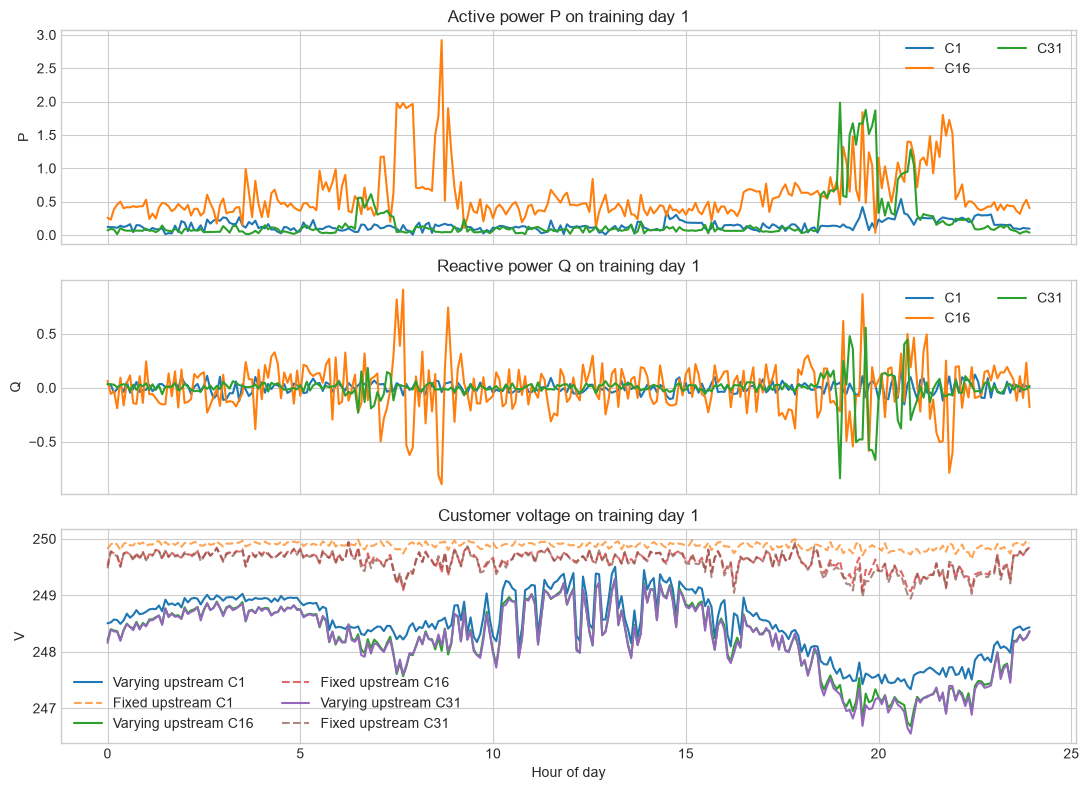

In [6]:
# There are 12 five-minute samples per hour and 288 samples per day.
STEPS_PER_DAY = 24 * 60 // 5
available_days = len(P_mv_tr) // STEPS_PER_DAY
if DAY_TO_PLOT < 1 or DAY_TO_PLOT > available_days:
    raise ValueError(f"DAY_TO_PLOT must be between 1 and {available_days}.")

customer_indices = [customer - 1 for customer in CUSTOMERS_TO_PLOT]
if min(customer_indices) < 0 or max(customer_indices) >= C:
    raise ValueError(f"CUSTOMERS_TO_PLOT must contain numbers from 1 to {C}.")

start = (DAY_TO_PLOT - 1) * STEPS_PER_DAY
end = start + STEPS_PER_DAY
hours = np.arange(STEPS_PER_DAY) * 5 / 60

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for axis, matrix, label in zip(
    axes[:2],
    [P_mv_tr, Q_mv_tr],
    ["Active power P", "Reactive power Q"],
):
    for customer, index in zip(CUSTOMERS_TO_PLOT, customer_indices):
        axis.plot(hours, matrix[start:end, index], label=f"C{customer}")
    axis.set_ylabel(label.split()[-1])
    axis.set_title(f"{label} on training day {DAY_TO_PLOT}")

for customer, index in zip(CUSTOMERS_TO_PLOT, customer_indices):
    axes[2].plot(
        hours,
        V_mv_tr[start:end, index],
        label=f"Varying upstream C{customer}",
    )
    axes[2].plot(
        hours,
        V_lv_tr[start:end, index],
        linestyle="--",
        alpha=0.7,
        label=f"Fixed upstream C{customer}",
    )

axes[2].set_ylabel("V")
axes[2].set_title(f"Customer voltage on training day {DAY_TO_PLOT}")
for axis in axes:
    axis.legend(loc="best", ncol=2)
axes[-1].set_xlabel("Hour of day")
plt.tight_layout()
plt.show()

#### 2.3.4 Prepare the controlled model inputs

The P/Q-only model receives 62 inputs. The P/Q + Vref model also receives C1-C3 voltage, and both models predict C4-C31.

The next cell only assembles the matrices. Scaling is fitted separately inside each training fold.

<font color='red'>**<u>Note</u>:**</font> Fit every scaler on the corresponding fold's training rows only. Do not use validation or test data.

In [7]:
REFERENCE_INDICES = np.array(
    REFERENCE_CUSTOMERS,
    dtype=int,
) - 1
if (
    len(REFERENCE_INDICES) == 0
    or len(np.unique(REFERENCE_INDICES)) != len(REFERENCE_INDICES)
    or REFERENCE_INDICES.min() < 0
    or REFERENCE_INDICES.max() >= C
):
    raise ValueError(
        f"REFERENCE_CUSTOMERS must contain unique customer numbers from 1 to {C}."
    )

TARGET_INDICES = np.array(
    [index for index in range(C) if index not in set(REFERENCE_INDICES)]
)
CORE_MODEL_NAMES = ["PQ_only", "PQ_plus_Vref"]
CORE_MODEL_LABELS = {
    "PQ_only": "P/Q only",
    "PQ_plus_Vref": "P/Q + Vref",
}

X_CORE_TRAIN = {
    "PQ_only": PQ_mv_tr,
    "PQ_plus_Vref": np.column_stack(
        [PQ_mv_tr, V_mv_tr[:, REFERENCE_INDICES]]
    ).astype(np.float32),
}
X_CORE_TEST = {
    "PQ_only": PQ_mv_te,
    "PQ_plus_Vref": np.column_stack(
        [PQ_mv_te, V_mv_te[:, REFERENCE_INDICES]]
    ).astype(np.float32),
}
Y_CORE_TRAIN = V_mv_tr[:, TARGET_INDICES]

expected_vref_inputs = PQ_mv_tr.shape[1] + len(REFERENCE_INDICES)
expected_targets = C - len(REFERENCE_INDICES)
assert X_CORE_TRAIN["PQ_only"].shape == PQ_mv_tr.shape
assert X_CORE_TRAIN["PQ_plus_Vref"].shape == (
    len(PQ_mv_tr),
    expected_vref_inputs,
)
assert Y_CORE_TRAIN.shape == (len(V_mv_tr), expected_targets)
assert X_CORE_TEST["PQ_only"].shape == PQ_mv_te.shape
assert X_CORE_TEST["PQ_plus_Vref"].shape == (
    len(PQ_mv_te),
    expected_vref_inputs,
)

print("Reference customers:", REFERENCE_CUSTOMERS)
print("Training inputs:", {name: data.shape for name, data in X_CORE_TRAIN.items()})
print("Training targets:", Y_CORE_TRAIN.shape)
print("Test inputs:", {name: data.shape for name, data in X_CORE_TEST.items()})


Reference customers: [1, 2, 3]
Training inputs: {'PQ_only': (6048, 62), 'PQ_plus_Vref': (6048, 65)}
Training targets: (6048, 28)
Test inputs: {'PQ_only': (2016, 62), 'PQ_plus_Vref': (2016, 65)}


### 2.4 Understand the MV effect

When the customer P/Q profiles match, the voltage difference between the two scenarios represents the effect of the upstream MV variation on customer voltage:

`MV effect = varying-upstream voltage - fixed-upstream voltage`

A negative value means that the varying-upstream case has lower customer voltage than the fixed-upstream reference. A larger absolute value means a stronger effect.

#### 2.4.1 Observe the MV effect over time

The next cell summarises the complete training period and plots the feeder-average effect for one training day. It answers how the MV effect changes during the day.

,quantity,training MV effect (V)
0,mean,-1.3211
1,standard deviation,0.5478
2,minimum,-2.4770
3,maximum,0.0202


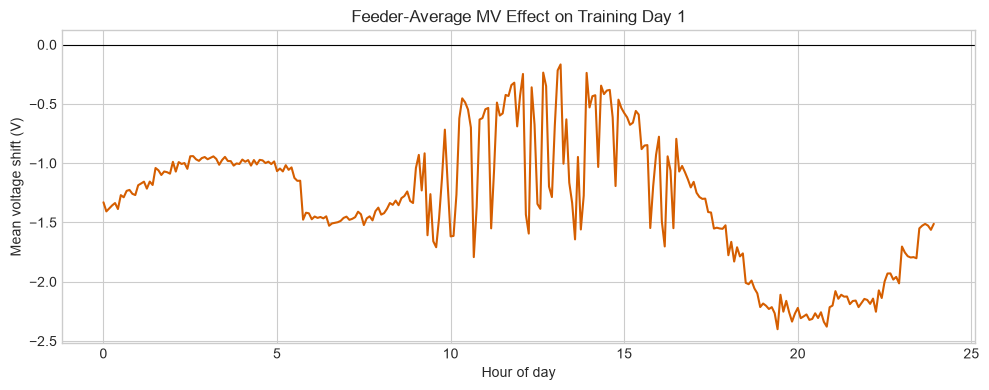

In [8]:
mv_effect_training = V_mv_tr - V_lv_tr
mv_effect_test = V_mv_te - V_lv_te  # Used after the final test in the exercises.

effect_summary = pd.DataFrame(
    {
        "quantity": ["mean", "standard deviation", "minimum", "maximum"],
        "training MV effect (V)": [
            mv_effect_training.mean(),
            mv_effect_training.std(),
            mv_effect_training.min(),
            mv_effect_training.max(),
        ],
    }
)
display(effect_summary.round(4))

available_days = len(mv_effect_training) // STEPS_PER_DAY
if MV_EFFECT_DAY_TO_PLOT < 1 or MV_EFFECT_DAY_TO_PLOT > available_days:
    raise ValueError(
        f"MV_EFFECT_DAY_TO_PLOT must be between 1 and {available_days}."
    )

start = (MV_EFFECT_DAY_TO_PLOT - 1) * STEPS_PER_DAY
end = start + STEPS_PER_DAY
feeder_mean_effect = mv_effect_training[start:end].mean(axis=1)

plt.figure(figsize=(10, 4))
plt.plot(hours, feeder_mean_effect, color="#D55E00")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Hour of day")
plt.ylabel("Mean voltage shift (V)")
plt.title(f"Feeder-Average MV Effect on Training Day {MV_EFFECT_DAY_TO_PLOT}")
plt.tight_layout()
plt.show()

The time-varying feeder-average trace shows that matching customer P/Q does not always produce the same customer voltage. A P/Q-only model therefore cannot observe this part of the upstream movement.

#### 2.4.2 Compare the MV effect by phase and feeder position

The **RMS MV-effect magnitude** summarises the voltage change for each customer over the complete training period. Plotting it against phase and upstream hops shows whether the effect is feeder-wide and how it varies with network position.

,phase,mean,minimum,maximum
0,1,1.4675,1.4657,1.4684
1,2,1.4400,1.4388,1.4405
2,3,1.3778,1.3768,1.3783


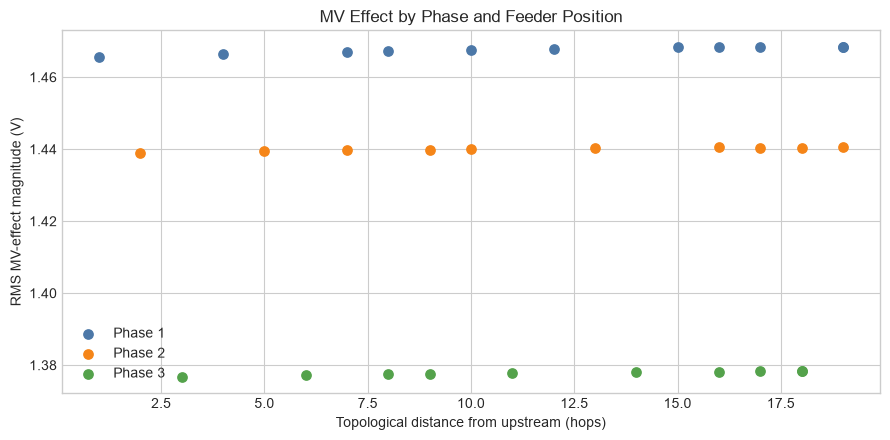

In [9]:
topology = pd.read_csv(
    TUTORIAL_DIRECTORY / "network" / "customer_topology.csv"
).sort_values("customer")
if len(topology) != C:
    raise ValueError(f"Topology contains {len(topology)} customers; expected {C}.")

customer_mv_effect = topology[["customer", "phase", "hops"]].copy()
customer_mv_effect["RMS MV effect (V)"] = np.sqrt(
    np.mean(mv_effect_training ** 2, axis=0)
)

phase_summary = (
    customer_mv_effect.groupby("phase")["RMS MV effect (V)"]
    .agg(mean="mean", minimum="min", maximum="max")
    .reset_index()
)
display(phase_summary.round(4))

phase_colours = {1: "#4C78A8", 2: "#F58518", 3: "#54A24B"}
plt.figure(figsize=(9, 4.5))
for phase, group in customer_mv_effect.groupby("phase"):
    plt.scatter(
        group["hops"],
        group["RMS MV effect (V)"],
        label=f"Phase {phase}",
        color=phase_colours[phase],
        s=45,
    )

plt.xlabel("Topological distance from upstream (hops)")
plt.ylabel("RMS MV-effect magnitude (V)")
plt.title("MV Effect by Phase and Feeder Position")
plt.legend()
plt.tight_layout()
plt.show()

In this simulated feeder, every customer is affected by the MV variation. The points form clear phase groups, and customers farther downstream within each phase generally have a slightly larger RMS magnitude. This motivates using one reference voltage per phase.

<font color='red'>**<u>Note</u>:**</font> RMS here summarises the voltage difference between two controlled scenarios. It is not model prediction RMSE and is not added to the model inputs.

### 2.5 Build the modelling workflow

#### 2.5.1 Define the neural network

As in Part 1, both models use one hidden layer. They differ only in input dimension while sharing the hidden size, activation and 28 voltage outputs.

| Component | Fixed choice |
|---|---|
| Hidden layers | One |
| Loss | MSE |
| Initialisation | Xavier uniform weights and zero bias |
| Scaling | MinMaxScaler |
| Output layer | Linear |
| Optimiser | Adam |

In [10]:
class NNi(nn.Module):
    """One-hidden-layer network for P/Q-to-voltage estimation."""

    def __init__(self, in_dim, out_dim, hidden_neurons, activation="tanh"):
        super().__init__()
        activations = {
            "tanh": nn.Tanh,
            "relu": nn.ReLU,
            "swish": nn.SiLU,
        }
        if activation not in activations:
            raise ValueError(f"Unsupported activation: {activation}")

        self.network = nn.Sequential(
            nn.Linear(in_dim, hidden_neurons),
            activations[activation](),
            nn.Linear(hidden_neurons, out_dim),
        )

        for layer in self.modules():
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, inputs):
        return self.network(inputs)

#### 2.5.2 Define blocked folds and fold-specific scaling

Nearby time samples are strongly related, so each validation period remains consecutive instead of randomly mixing individual rows. Each fold fits its scalers on that fold's training blocks only.

<font color='red'>**<u>Note</u>:**</font> Do not refit a scaler on validation or test data.

In [11]:
def blocked_kfold_indices(n_instances, k=KFOLDS):
    """Create k adjacent validation blocks without shuffling time."""
    fold_sizes = [n_instances // k] * k
    for i in range(n_instances % k):
        fold_sizes[i] += 1

    all_indices = np.arange(n_instances)
    folds = []
    start = 0
    for fold_size in fold_sizes:
        end = start + fold_size
        validation_indices = all_indices[start:end]
        training_indices = np.concatenate(
            [all_indices[:start], all_indices[end:]]
        )
        folds.append((training_indices, validation_indices))
        start = end
    return folds


def prepare_fold(model_name, training_indices, validation_indices):
    """Fit fold scalers on training blocks and transform both parts."""
    X = X_CORE_TRAIN[model_name]
    X_train, X_val = X[training_indices], X[validation_indices]
    Y_train = Y_CORE_TRAIN[training_indices]

    input_scaler = MinMaxScaler().fit(X_train)
    output_scaler = MinMaxScaler().fit(Y_train)

    return (
        input_scaler.transform(X_train).astype(np.float32),
        output_scaler.transform(Y_train).astype(np.float32),
        input_scaler.transform(X_val).astype(np.float32),
        output_scaler,
    )

#### 2.5.3 Define training and prediction

The same training function is reused for K-fold comparison, seed comparison and final training. Predictions are converted back to volts before errors are calculated.

In [12]:
def train_model(model, X_train, Y_train, config, seed):
    """Train one model with mini-batch Adam optimisation."""
    training_data = TensorDataset(
        torch.from_numpy(X_train),
        torch.from_numpy(Y_train),
    )
    generator = torch.Generator().manual_seed(seed)
    training_loader = DataLoader(
        training_data,
        batch_size=config["batch_size"],
        shuffle=True,
        generator=generator,
    )

    model = model.to(DEVICE)
    optimiser = torch.optim.Adam(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    loss_fn = nn.MSELoss()

    for _ in range(config["epochs"]):
        model.train()
        for X_batch, Y_batch in training_loader:
            X_batch = X_batch.to(DEVICE)
            Y_batch = Y_batch.to(DEVICE)

            optimiser.zero_grad()
            loss = loss_fn(model(X_batch), Y_batch)
            loss.backward()
            optimiser.step()

    return model


def predict_unscaled(model, X_scaled, output_scaler):
    """Predict voltage and return it in volts rather than scaled units."""
    model.eval()
    with torch.inference_mode():
        scaled_prediction = model(
            torch.from_numpy(X_scaled).to(DEVICE)
        ).cpu().numpy()
    return output_scaler.inverse_transform(scaled_prediction)

#### 2.5.4 Define K-fold evaluation and grid search

Every configuration uses the same blocked folds. Validation RMSE is calculated for each model, and their average selects the shared configuration. The seed comparison uses the same blocked-validation rule.

In [13]:
def calculate_rmse(actual, predicted):
    return float(np.sqrt(np.mean((actual - predicted) ** 2)))


def evaluate_config(config, seed=SEED):
    """Evaluate one shared configuration on all blocked folds."""
    fold_rows = []
    for fold, (training_indices, validation_indices) in enumerate(
        blocked_kfold_indices(len(Y_CORE_TRAIN)),
        start=1,
    ):
        Y_validation = Y_CORE_TRAIN[validation_indices]
        for model_name in CORE_MODEL_NAMES:
            X_train, Y_train, X_val, output_scaler = prepare_fold(
                model_name,
                training_indices,
                validation_indices,
            )
            set_seed(seed)
            model = NNi(
                in_dim=X_train.shape[1],
                out_dim=Y_train.shape[1],
                hidden_neurons=int(config["hidden_neurons"]),
                activation=str(config["activation"]),
            )
            model = train_model(model, X_train, Y_train, config, seed)
            prediction = predict_unscaled(model, X_val, output_scaler)
            fold_rows.append(
                {
                    "fold": fold,
                    "model": model_name,
                    "RMSE (V)": calculate_rmse(Y_validation, prediction),
                }
            )

    fold_results = pd.DataFrame(fold_rows)
    grouped = fold_results.groupby("model")["RMSE (V)"]
    mean_scores = grouped.mean()
    std_scores = grouped.std(ddof=0)
    summary = {
        "PQ_only_RMSE_kfold": float(mean_scores["PQ_only"]),
        "PQ_only_RMSE_std": float(std_scores["PQ_only"]),
        "PQ_plus_Vref_RMSE_kfold": float(mean_scores["PQ_plus_Vref"]),
        "PQ_plus_Vref_RMSE_std": float(std_scores["PQ_plus_Vref"]),
    }
    summary["joint_RMSE_kfold"] = 0.5 * (
        summary["PQ_only_RMSE_kfold"]
        + summary["PQ_plus_Vref_RMSE_kfold"]
    )
    return summary, fold_results


def run_grid_search(search_space=SEARCH_SPACE):
    """Evaluate and rank every shared configuration."""
    configurations = [
        dict(zip(search_space, values))
        for values in itertools.product(*search_space.values())
    ]
    rows = []
    for number, config in enumerate(configurations, start=1):
        start_time = time.time()
        summary, _ = evaluate_config(config)
        rows.append({**config, **summary, "train_time_s": time.time() - start_time})
        print(
            f"Configuration {number}/{len(configurations)}: "
            f"joint RMSE={summary['joint_RMSE_kfold']:.6f} V"
        )
    return pd.DataFrame(rows).sort_values("joint_RMSE_kfold").reset_index(drop=True)


def run_seed_search(config, seeds=SEEDS_TO_TRY):
    """Compare seeds using the selected configuration and blocked folds."""
    rows = []
    for seed in seeds:
        summary, _ = evaluate_config(config, seed=seed)
        rows.append({"seed": seed, **summary})
        print(
            f"Seed {seed}: joint validation RMSE="
            f"{summary['joint_RMSE_kfold']:.6f} V"
        )
    return pd.DataFrame(rows).sort_values("joint_RMSE_kfold").reset_index(drop=True)

### 2.6 Select and train the final models

#### 2.6.1 Select hyperparameters with blocked K-fold validation

Every Part 2 configuration trains two models, so the tutorial keeps a smaller search space.

| Hyperparameter | Part 1 tutorial | Part 2 tutorial |
|---|---|---|
| Hidden neurons | 93 or 155 | 93 or 155 |
| Activation | `tanh` | `tanh` |
| Learning rate | `1e-3`, `1e-4` | `1e-3`, `1e-4` |
| Weight decay | `1e-4`, `1e-5` | `1e-5` |
| Batch size | 72 | 72 |
| Epochs | 1,000 or 2,000 | 300 |

The included CSV stores the completed training-only K-fold results so the standard run remains quick. Set `RUN_SEARCH=True` to reproduce every fit in the displayed search space.

<font color='red'>**<u>Note</u>:**</font> Select hyperparameters using blocked-validation results only. Do not use the held-out test period to rank configurations.

In [14]:
fold_summary = pd.DataFrame(
    [
        {
            "fold": fold,
            "training rows": len(training_indices),
            "validation rows": len(validation_indices),
            "validation range (1-based)": (
                f"{validation_indices[0] + 1}–{validation_indices[-1] + 1}"
            ),
        }
        for fold, (training_indices, validation_indices) in enumerate(
            blocked_kfold_indices(len(Y_CORE_TRAIN)), start=1
        )
    ]
)
display(fold_summary)

CORE_SEARCH_FILE = TUTORIAL_DIRECTORY / "MV_core_search_results.csv"
if RUN_SEARCH:
    search_results = run_grid_search()
    search_results.to_csv(CORE_SEARCH_FILE, index=False)
    search_source = "newly calculated results"
else:
    if not CORE_SEARCH_FILE.is_file():
        raise FileNotFoundError("MV_core_search_results.csv was not found.")
    search_results = pd.read_csv(CORE_SEARCH_FILE)
    search_source = f"included results: {CORE_SEARCH_FILE.name}"

search_results = search_results.sort_values(
    "joint_RMSE_kfold"
).reset_index(drop=True)
columns_to_show = [
    "hidden_neurons", "activation", "lr", "weight_decay",
    "batch_size", "epochs", "PQ_only_RMSE_kfold",
    "PQ_plus_Vref_RMSE_kfold", "joint_RMSE_kfold",
]

print(f"Using {search_source}")
display(search_results[columns_to_show].round(6))

best_row = search_results.iloc[0]
best_config = {
    "hidden_neurons": int(best_row["hidden_neurons"]),
    "activation": str(best_row["activation"]),
    "lr": float(best_row["lr"]),
    "weight_decay": float(best_row["weight_decay"]),
    "batch_size": int(best_row["batch_size"]),
    "epochs": int(best_row["epochs"]),
}

print("Selected shared configuration:")
for name, value in best_config.items():
    print(f"  {name}: {value}")
print(f"Mean joint blocked K-fold RMSE: {best_row['joint_RMSE_kfold']:.6f} V")

,fold,training rows,validation rows,validation range (1-based)
0,1,4032,2016,1–2016
1,2,4032,2016,2017–4032
2,3,4032,2016,4033–6048


Using included results: MV_core_search_results.csv


,hidden_neurons,activation,lr,weight_decay,batch_size,epochs,PQ_only_RMSE_kfold,PQ_plus_Vref_RMSE_kfold,joint_RMSE_kfold
0,155,tanh,0.0001,0.00001,72,300,0.570946,0.015565,0.293255
1,93,tanh,0.0001,0.00001,72,300,0.569190,0.018526,0.293858
2,93,tanh,0.0010,0.00001,72,300,0.579192,0.019352,0.299272
3,155,tanh,0.0010,0.00001,72,300,0.580711,0.019667,0.300189


Selected shared configuration:
  hidden_neurons: 155
  activation: tanh
  lr: 0.0001
  weight_decay: 1e-05
  batch_size: 72
  epochs: 300
Mean joint blocked K-fold RMSE: 0.293255 V


#### 2.6.2 Compare random seeds

Keep the selected hyperparameters fixed and change only the seed. As in Part 1, seeds are compared by mean blocked-validation RMSE rather than training or test error.

Part 2 trains two models for each fold, so the tutorial compares seeds 0-2. Set `RUN_SEED_SEARCH=True` to reproduce all blocked-validation fits.

In [15]:
# Hyperparameters stay fixed while only the random seed changes.
if RUN_SEED_SEARCH:
    seed_results = run_seed_search(best_config, seeds=SEEDS_TO_TRY)
    selected_seed = int(seed_results.iloc[0]["seed"])
    display(seed_results.round(6))
else:
    selected_seed = REPORTED_SELECTED_SEED
    print(
        "Using the selected seed from the completed methodology run. "
        "Set RUN_SEED_SEARCH=True to reproduce the comparison."
    )

print(f"Seeds considered: {SEEDS_TO_TRY}")
print(f"Selected seed: {selected_seed}")

Using the selected seed from the completed methodology run. Set RUN_SEED_SEARCH=True to reproduce the comparison.
Seeds considered: [0, 1, 2]
Selected seed: 0


#### 2.6.3 Train the final models

The hyperparameters and seed are now fixed. Refit the scalers on all 21 training days and train both final models. The test voltage targets remain unused.

In [16]:
FINAL_MODELS = {}
input_scalers_full = {}

output_scaler_full = MinMaxScaler().fit(Y_CORE_TRAIN)
Y_train_full = output_scaler_full.transform(Y_CORE_TRAIN).astype(np.float32)

for model_name in CORE_MODEL_NAMES:
    input_scaler = MinMaxScaler().fit(X_CORE_TRAIN[model_name])
    X_train_full = input_scaler.transform(
        X_CORE_TRAIN[model_name]
    ).astype(np.float32)

    set_seed(selected_seed)
    final_model = NNi(
        in_dim=X_train_full.shape[1],
        out_dim=Y_train_full.shape[1],
        hidden_neurons=best_config["hidden_neurons"],
        activation=best_config["activation"],
    )
    final_model = train_model(
        final_model,
        X_train_full,
        Y_train_full,
        best_config,
        selected_seed,
    )
    FINAL_MODELS[model_name] = final_model
    input_scalers_full[model_name] = input_scaler

print("Final models trained on all 21 training days.")
print(f"Selected seed: {selected_seed}")
print("The test voltage targets have not been used.")

Final models trained on all 21 training days.
Selected seed: 0
The test voltage targets have not been used.


### 2.7 Evaluate the held-out test period

#### 2.7.1 Check overall accuracy

<font color='red'>**<u>Note</u>:**</font> Use the test period only after the hyperparameters, random seed and final models have been fixed.

- RMSE summarises overall error and gives larger errors more weight;
- MAE reports the average absolute voltage difference; and
- the parity plots compare every estimated voltage with its simulated target.

,model,inputs,targets,RMSE (V),MAE (V)
0,P/Q only,62,28,0.632844,0.468440
1,P/Q + Vref,65,28,0.015368,0.010661


RMSE reduction after adding Vref: 97.6%
Customers improved: 28/28


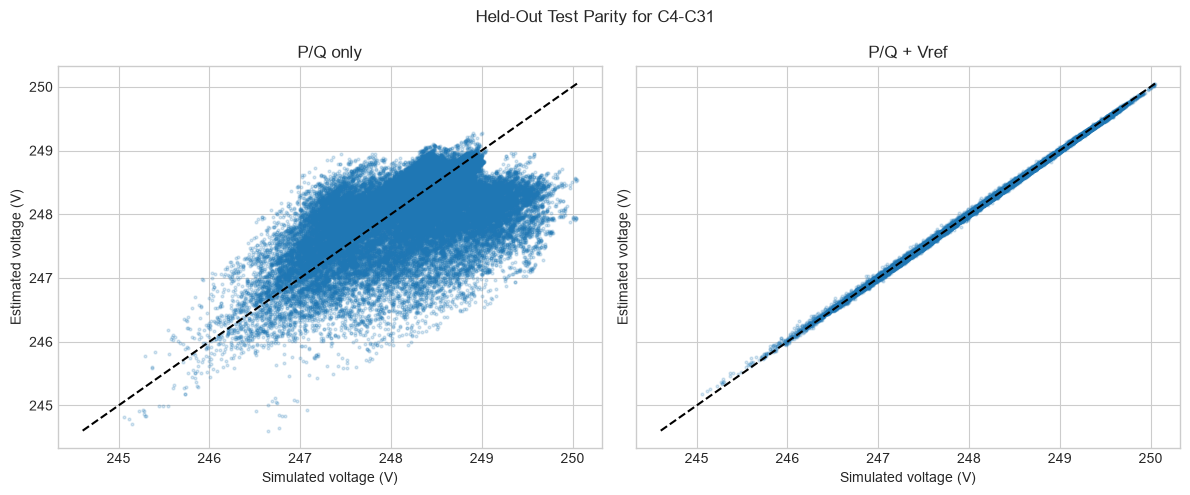

In [17]:
Y_CORE_TEST = V_mv_te[:, TARGET_INDICES]
test_predictions = {}
overall_rows = []
customer_rows = []

for model_name in CORE_MODEL_NAMES:
    X_test_scaled = input_scalers_full[model_name].transform(
        X_CORE_TEST[model_name]
    ).astype(np.float32)
    prediction = predict_unscaled(
        FINAL_MODELS[model_name],
        X_test_scaled,
        output_scaler_full,
    )
    test_predictions[model_name] = prediction
    error = prediction - Y_CORE_TEST

    overall_rows.append(
        {
            "model": CORE_MODEL_LABELS[model_name],
            "inputs": X_CORE_TEST[model_name].shape[1],
            "targets": Y_CORE_TEST.shape[1],
            "RMSE (V)": np.sqrt(np.mean(error ** 2)),
            "MAE (V)": np.mean(np.abs(error)),
        }
    )
    for local_index, customer_index in enumerate(TARGET_INDICES):
        customer_error = error[:, local_index]
        customer_rows.append(
            {
                "customer": f"C{customer_index + 1}",
                "model": CORE_MODEL_LABELS[model_name],
                "RMSE (V)": np.sqrt(np.mean(customer_error ** 2)),
            }
        )

overall_core_metrics = pd.DataFrame(overall_rows)
per_customer_core_metrics = pd.DataFrame(customer_rows)
customer_core_rmse = per_customer_core_metrics.pivot(
    index="customer",
    columns="model",
    values="RMSE (V)",
).reindex([f"C{index + 1}" for index in TARGET_INDICES])

pq_rmse = float(
    overall_core_metrics.loc[
        overall_core_metrics["model"] == "P/Q only", "RMSE (V)"
    ].iloc[0]
)
vref_rmse = float(
    overall_core_metrics.loc[
        overall_core_metrics["model"] == "P/Q + Vref", "RMSE (V)"
    ].iloc[0]
)
customers_improved = int(
    (customer_core_rmse["P/Q + Vref"] < customer_core_rmse["P/Q only"]).sum()
)

display(overall_core_metrics.round(6))
print(f"RMSE reduction after adding Vref: {100 * (pq_rmse - vref_rmse) / pq_rmse:.1f}%")
print(f"Customers improved: {customers_improved}/{len(customer_core_rmse)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
plot_min = min(
    float(Y_CORE_TEST.min()),
    *(float(prediction.min()) for prediction in test_predictions.values()),
)
plot_max = max(
    float(Y_CORE_TEST.max()),
    *(float(prediction.max()) for prediction in test_predictions.values()),
)

for axis, model_name in zip(axes, CORE_MODEL_NAMES):
    axis.scatter(
        Y_CORE_TEST.ravel(),
        test_predictions[model_name].ravel(),
        s=4,
        alpha=0.18,
    )
    axis.plot([plot_min, plot_max], [plot_min, plot_max], "--", color="black")
    axis.set_title(CORE_MODEL_LABELS[model_name])
    axis.set_xlabel("Simulated voltage (V)")
    axis.set_ylabel("Estimated voltage (V)")

fig.suptitle("Held-Out Test Parity for C4-C31")
fig.tight_layout()
plt.show()

#### 2.7.2 Compare test RMSE for each customer

An overall metric can hide differences between customers. Compare P/Q-only and P/Q + Vref RMSE for the 28 non-reference customers and check whether the improvement is widespread.

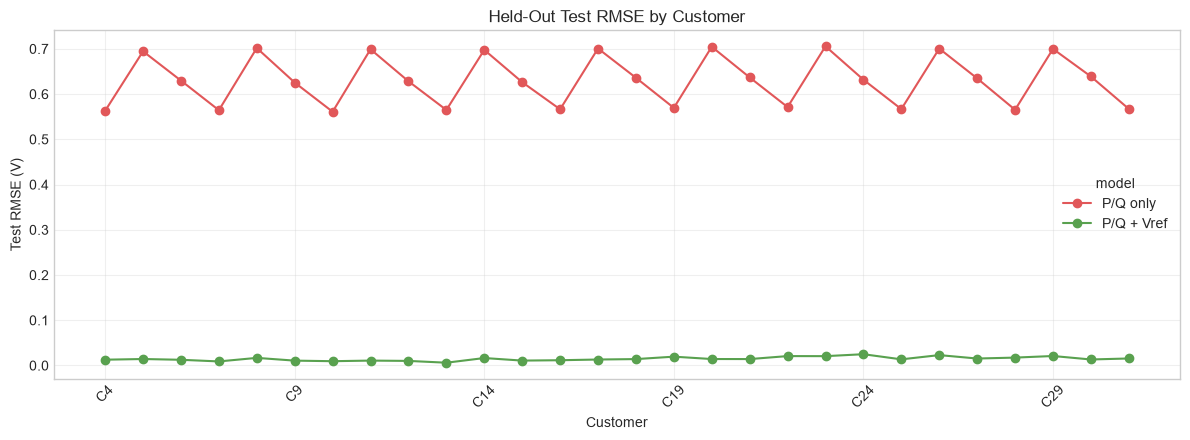

In [18]:
customer_core_rmse[["P/Q only", "P/Q + Vref"]].plot(
    marker="o",
    figsize=(12, 4.5),
    color=["#E15759", "#59A14F"],
)
plt.xlabel("Customer")
plt.ylabel("Test RMSE (V)")
plt.title("Held-Out Test RMSE by Customer")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Result check**

- Compare both models on the same C4-C31 targets;
- adding Vref should reduce RMSE for most customers; and
- the P/Q + Vref parity points should lie closer to the identity line.

<font color='red'>**<u>Note</u>:**</font> Do not change model settings after viewing the test results and then test again on the same period.

**Expected result**

In the saved run, P/Q-only test RMSE is about **0.6328 V**. Adding Vref reduces it to about **0.0154 V**, a **97.6%** reduction, and improves **28/28** non-reference customers.

The complete teaching flow is: **controlled data comparison → MV-effect analysis → blocked validation → fixed hyperparameters and seed → full training → one final test**.

These values apply to the supplied simulated feeder and the C1-C3 reference choice; a different feeder or reference placement should be checked again.

## 3. Exercises

Use the existing variables and functions and change only the stated values.

<font color='red'>**<u>Note</u>:**</font> Complete the Section 2 final test before using test-period quantities in the exercises. Do not use the exercise findings to retune the models.

### Exercise: Analyse MV effects and reference voltage

**E.1 — Inspect the MV effect for one customer**

- Choose one customer and one test day;
- plot `V_MV - V_LV` for that customer;
- report the mean and standard deviation; and
- describe whether the effect is persistent or concentrated in shorter periods.

**E.2 — Check whether Vref helps customers consistently**

- Use `customer_core_rmse` from Section 2.7.2;
- calculate the RMSE reduction from P/Q only to P/Q + Vref for C4-C31;
- identify the customer with the largest absolute reduction; and
- report how many customers improve.

**E.3 — Use topology to explain customer-level MV-effect differences**

- Use `customer_mv_effect` from Section 2.4.2;
- compare mean RMS MV-effect magnitude across the three phases;
- calculate the correlation between hops and RMS magnitude within each phase; and
- describe the phase and feeder-position patterns in this simulated network.

Complete solutions are provided in `Tutorial_2_MV_Effects_Reference_Voltage_Exercise_Solutions.ipynb`.

In [19]:
# Suggested starting point for E.1
# customer_number = 16
# day_number = 1
# customer_index = customer_number - 1
# start = (day_number - 1) * STEPS_PER_DAY
# end = start + STEPS_PER_DAY
# customer_effect = V_mv_te[start:end, customer_index] - V_lv_te[start:end, customer_index]


In [20]:
# Suggested starting point for E.2
# customer_benefit = customer_core_rmse.copy()
# customer_benefit["RMSE reduction (V)"] = (
#     customer_benefit["P/Q only"] - customer_benefit["P/Q + Vref"]
# )
# display(customer_benefit.sort_values("RMSE reduction (V)", ascending=False))


In [21]:
# Suggested starting point for E.3
# phase_means = customer_mv_effect.groupby("phase")["RMS MV effect (V)"].mean()
# phase_correlations = customer_mv_effect.groupby("phase").apply(
#     lambda group: group["hops"].corr(group["RMS MV effect (V)"]),
#     include_groups=False,
# )
# display(phase_means.round(4))
# display(phase_correlations.round(4))

## 4. Simulation Workspace

Write and run your exercise code below.


In [22]:
# Assemble and run the code required for Exercises E.1–E.3 here.
